SUAVIZADO DE PUNTO DE INTERES

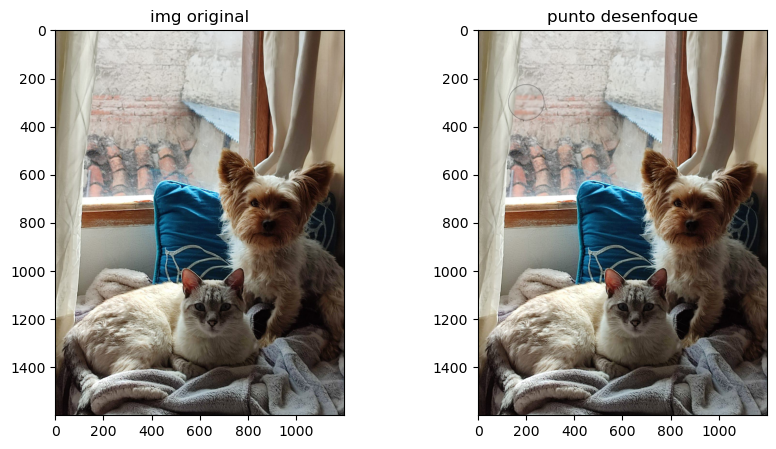

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def desenfoquePDT(img, centro, x, y):
    img1 = np.copy(img)
    valx,valy = centro
    mediax = x//2
    mediaY = y//2
    mascara = np.zeros_like(img, dtype=np.uint8)
    cv2.ellipse(mascara,(valx,valy),(mediax,mediaY),0,0,360,(255,255,255),-1)
    img_mask = cv2.bitwise_and(img,mascara)
    desenmfoque = cv2.GaussianBlur(img_mask,(15,15),0)
    img1[mascara!=0] = desenmfoque[mascara!=0]
    return img1

img = cv2.imread('imagentango.jpg')
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_desenfoque = desenfoquePDT(imgRGB,(200,300),150,150)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('img original')
plt.imshow(imgRGB, cmap='gray')

plt.subplot(1,2,2)
plt.title('punto desenfoque')
plt.imshow(img_desenfoque, cmap='gray')

plt.show()


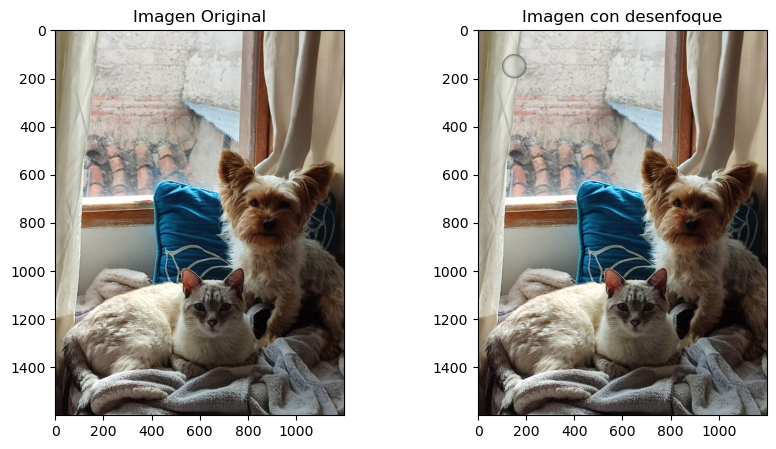

In [3]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 

def desenfoqueRoi(img,centro,x,y):
    img1=np.copy(img)  # Copia la imagen original para no modificarla directamente 
    valx,valy=centro
    mediox=x//2
    medioy=y//2
    mascara=np.zeros_like(img,dtype=np.uint8)
    cv2.ellipse(mascara,(valx,valy),(mediox,medioy),0,0,360,(255,255,255),-1)  # Dibuja un elipse en la máscara 
    img_mask=cv2.bitwise_and(img1,mascara)  # Aplica la máscara a la imagen original 
    desenfoque=cv2.GaussianBlur(img_mask,(45,45),0)  # Aplica un desenfoque gaussiano a la región de interés 
    img1[mascara>0]=desenfoque[mascara>0]  # Reemplaza la región de interés en la imagen original con la versión desenfocada 
    return img1
img=cv2.imread('imagentango.jpg')
imagenRgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
imgDesenfoque=desenfoqueRoi(imagenRgb,(150,150),100,100)

plt.figure(figsize=(10, 5))
plt.subplot(121)

plt.imshow(imagenRgb)
plt.title('Imagen Original')

plt.subplot(122)
plt.imshow(imgDesenfoque)
plt.title('Imagen con desenfoque')

plt.show()

bordes y mascaras

C:\Users\usser\AppData\Local\Temp\ipykernel_17264\2582038810.py:33: RuntimeWarning: invalid value encountered in sqrt
  prew_mag=np.sqrt(prewittx*2+prewitty*2)


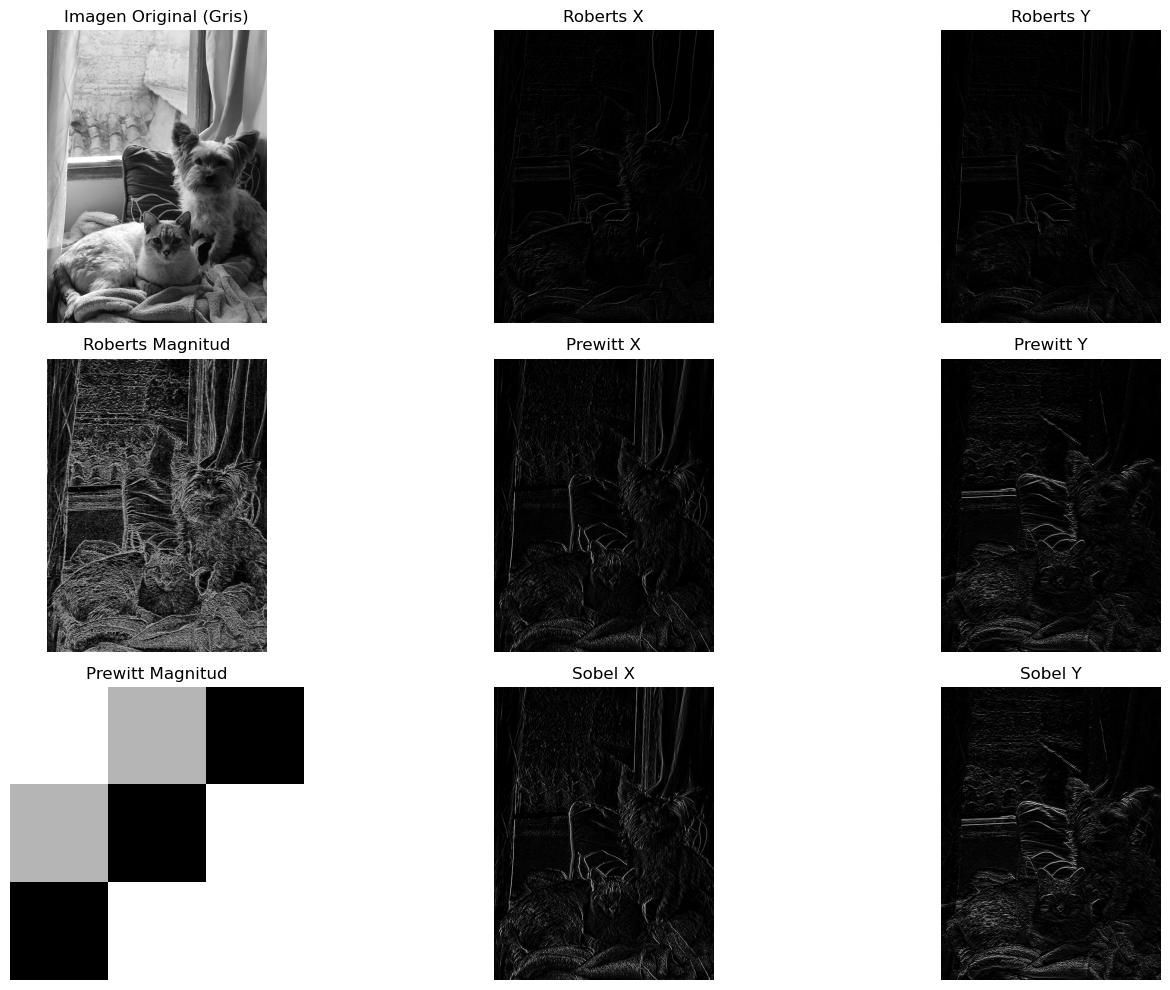

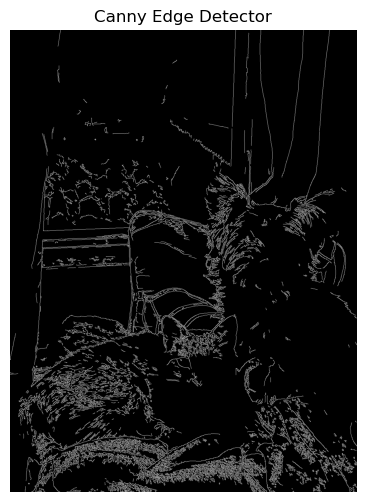

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('imagentango.jpg')
img_gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#KERNEL ROBERTS

robertsx=np.array([[-1,0],[0,1]])
robertsy=np.array([[0,-1],[1,0]])

#mostrar en x and y

img_robx=cv2.filter2D(img_gray, -1, robertsx)

img_roby=cv2.filter2D(img_gray, -1, robertsy)

#magnitud en roberts

rob_gMagnitud=np.sqrt(img_robx**2+img_roby**2)
rob_gdireccion=np.arctan2(img_roby, img_robx)


#filtro prewit

prewittx=np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
prewitty=np.array([[1,1,1], [0,0,0], [-1,-1,-1]])

img_prewx= cv2.filter2D(img_gray,-1,prewittx)
img_prewy= cv2.filter2D(img_gray,-1,prewitty)

prew_mag=np.sqrt(prewittx*2+prewitty*2)
prew_dir=np.arctan2(prewitty,prewittx)

#filtro sobel

solbelx=np.array([[1,0,-1], [2,0,-2], [1,0,-1]])
solbely=np.array([[1,2,1], [0,0,0], [-1,-2,-1]])

sobx_imge=cv2.filter2D(img_gray,-1, solbelx)
soby_imge=cv2.filter2D(img_gray,-1, solbely)

sobel_grad=np.sqrt(solbelx**2+solbely**2)
sob_dire=np.arctan2(solbely,solbelx)

canny=cv2.Canny(img_gray,100,200)


# Mostrar las imágenes con subplots
plt.figure(figsize=(15, 10))

plt.subplot(3, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Imagen Original (Gris)')
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(img_robx, cmap='gray')
plt.title('Roberts X')
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(img_roby, cmap='gray')
plt.title('Roberts Y')
plt.axis('off')

plt.subplot(3, 3, 4)
plt.imshow(rob_gMagnitud, cmap='gray')
plt.title('Roberts Magnitud')
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(img_prewx, cmap='gray')
plt.title('Prewitt X')
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(img_prewy, cmap='gray')
plt.title('Prewitt Y')
plt.axis('off')

plt.subplot(3, 3, 7)
plt.imshow(prew_mag, cmap='gray')
plt.title('Prewitt Magnitud')
plt.axis('off')

plt.subplot(3, 3, 8)
plt.imshow(sobx_imge, cmap='gray')
plt.title('Sobel X')
plt.axis('off')

plt.subplot(3, 3, 9)
plt.imshow(soby_imge, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')

plt.tight_layout()  # Ajusta el espaciado entre subplots
plt.show()

# Mostrar Canny aparte si no cabe bien en la cuadrícula anterior
plt.figure(figsize=(6, 6))
plt.subplot(1, 1, 1)
plt.imshow(canny, cmap='gray')
plt.title('Canny Edge Detector')
plt.axis('off')
plt.show()





roberts

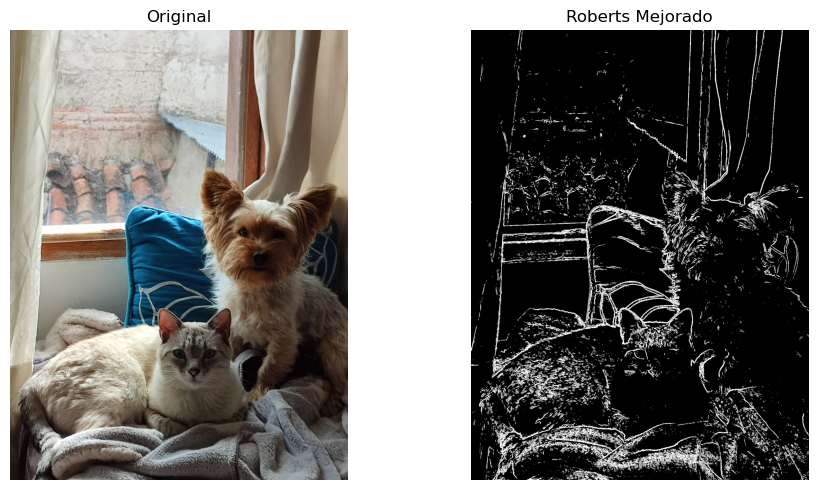

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img=cv2.imread('imagentango.jpg')
def roberts_mejorado(imagen):
    img_Gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    suavisado=cv2.GaussianBlur(img_Gray,(3,3),0)
    kernelX=np.array([[-2, 0], [0, 2]],dtype=np.float32)
    kernelY=np.array([[0, 2], [-2, 0]],dtype=np.float32)
    robX=cv2.filter2D(suavisado,cv2.CV_16S,kernelX)
    robY=cv2.filter2D(suavisado,cv2.CV_16S,kernelY)
    robert=cv2.addWeighted(np.abs(robX),0.7,np.abs(robY),0.7,0)
    #resaltar bordes
    _, bordes = cv2.threshold(robert, 30, 255, cv2.THRESH_BINARY)
    return bordes
resultado = roberts_mejorado(img)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Roberts Mejorado")
plt.imshow(resultado, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()

sobel mejorado

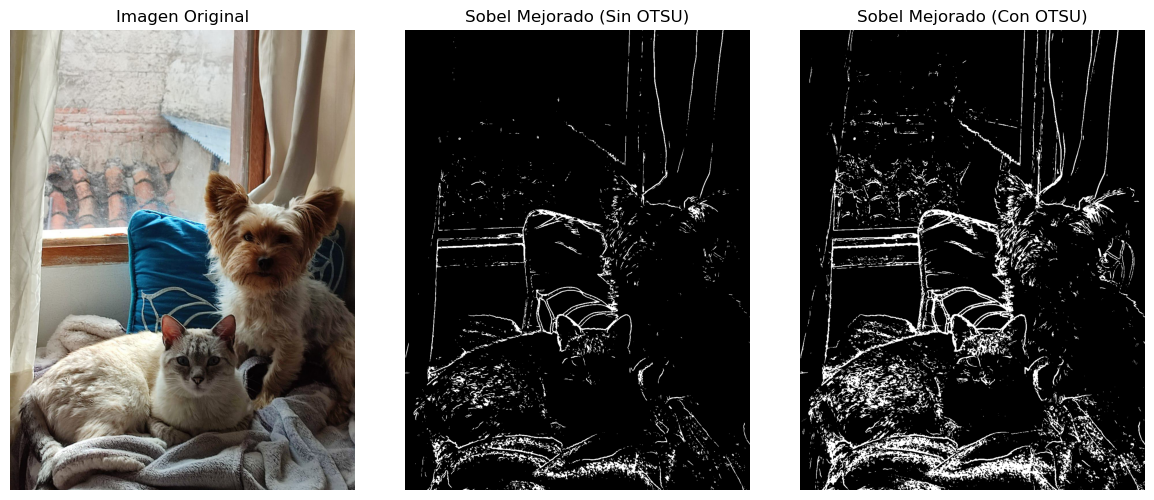

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagentango.jpg')

def sobel_mejorado(imagen, tam_kernel=3, umbral=30, usar_otsu=True):
   
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.GaussianBlur(img_gray, (3, 3), 0)

    sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=tam_kernel)
    sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=tam_kernel)

    magnitud = np.sqrt(sobelx**2 + sobely**2)

    magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    if usar_otsu:
        _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY)

    # Unir bordes rotos
    kernel_morf = np.ones((2, 2), np.uint8)
    bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_morf)
    return bordes

# Aplicar la función Sobel mejorado con y sin Otsu
bordes_sin_otsu = sobel_mejorado(img, umbral=50, usar_otsu=False)
bordes_con_otsu = sobel_mejorado(img, umbral=50, usar_otsu=True)

# Mostrar los resultados con subplots
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(bordes_sin_otsu, cmap='gray')
plt.title('Sobel Mejorado (Sin OTSU)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(bordes_con_otsu, cmap='gray')
plt.title('Sobel Mejorado (Con OTSU)')
plt.axis('off')

plt.tight_layout()
plt.show()

prewit mejorado

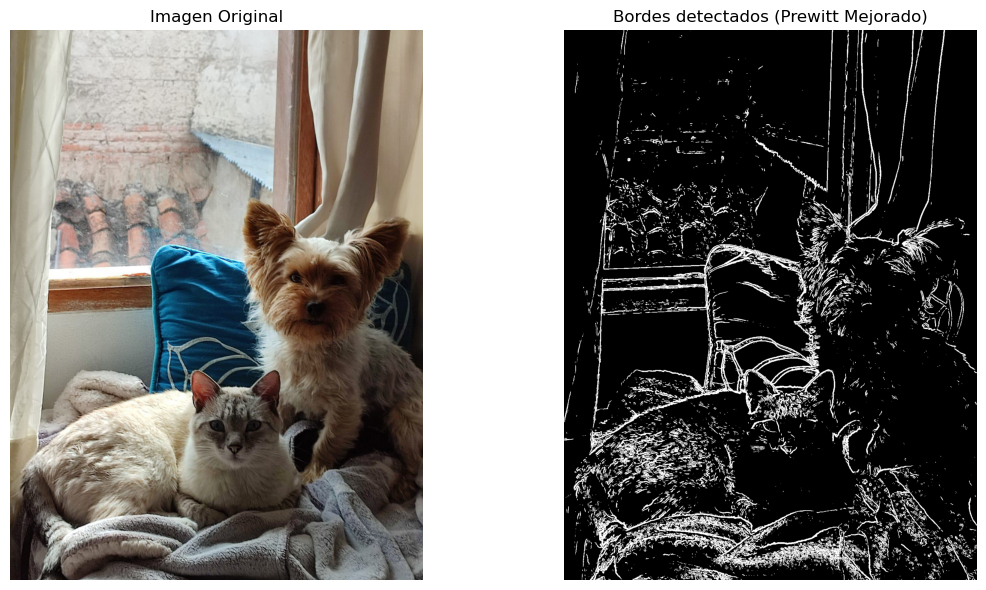

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Leer la imagen original
img = cv2.imread('imagentango.jpg')

def prewitt_mejor(imagen):
    # Convertir la imagen a escala de grises
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    # Suavizar la imagen para reducir ruido (mejora la detección de bordes)
    img_gray = cv2.GaussianBlur(img_gray, (3, 3), 0)
    
    # Definir los kernels de Prewitt en las direcciones X e Y
    prewittx = np.array([[3, 0, -3],
                         [3, 0, -3],
                         [3, 0, -3]], dtype=np.float32)
    prewitty = np.array([[3, 3, 3],
                         [0, 0, 0],
                         [-3, -3, -3]], dtype=np.float32)
    
    # Aplicar la convolución con cada kernel
    # Se utiliza cv2.CV_64F para capturar valores negativos
    grad_x = cv2.filter2D(img_gray, cv2.CV_64F, prewittx)
    grad_y = cv2.filter2D(img_gray, cv2.CV_64F, prewitty)
    
    # Calcular la magnitud del gradiente
    magnitud = np.sqrt(grad_x**2 + grad_y**2)
    
    # Normalizar la magnitud para que los valores estén entre 0 y 255
    magnitud_norm = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX)
    magnitud_norm = magnitud_norm.astype(np.uint8)
    
    # Aplicar un umbral para resaltar los bordes
    _, bordes = cv2.threshold(magnitud_norm, 30, 255, cv2.THRESH_BINARY)
    return bordes

# Procesar la imagen con el filtro Prewitt mejorado
resultado = prewitt_mejor(img)

# Mostrar la imagen original y el resultado de la detección de bordes
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resultado, cmap="gray")
plt.title("Bordes detectados (Prewitt Mejorado)")
plt.axis("off")

plt.tight_layout()
plt.show()
